In [179]:
import pandas as pd
from pathlib import Path
import numpy as np

#### **CONTEXTO E OBJETIVO**
* Os dados foram obtidos a partir do consumo da API da Gupy.
* O objetivo é analisar o mercado de vagas de dados dentro desse contexto. 
* Como está o mercado recentemente?

**Labels** utilizadas para obtenção de arquivos: <br>
* analista
* dados
* python
* administração
* engenharia
* desenvolvedor
* engenheiro
* cientista
* ciência
* bi
* analyst
* engineer
* scientist
* business
* devops
* back-end

In [192]:
# leitura dos múltiplos arquivos JSONS
path = Path ("../dados/vagas")

files = list(path.glob("*json"))

dfs = []

for file in files:
    df = pd.read_json(file)
    dfs.append(df)

arquivo_dados = pd.concat(dfs, ignore_index=True)
arquivo_dados.head

<bound method NDFrame.head of           id  companyId                                               name  \
0    9749257        400  Analista de Planejamento Financeiro Sr. (Foco ...   
1    9748351      23930                         ANALISTA ADMINISTRATIVO JR   
2    9740850        487                           Analista de Laboratório    
3    9738884        400             Analista de Planejamento Comercial Sr.   
4    9738834        400             Analista de Planejamento Comercial Jr.   
..       ...        ...                                                ...   
434   718626       2226                             Engenheiro(a) de Dados   
435  9741353      17527  Cientista de Dados | AWS | Python | Machine Le...   
436  9385227       7198    Pessoa Engenheira de Software - Back-end Python   
437  7407340      39703                   Analista Machine Learning/Python   
438  4738330      52441  Banco de Talentos WK Technology - Desenvolvime...   

                                 

In [181]:
df_dados = arquivo_dados[arquivo_dados["name"].str.contains("dados", case=False, na=False) |
                         arquivo_dados["description"].str.contains("dados", case=False, na=False)]
df_dados = df_dados.drop_duplicates(subset="id")
df_dados.count()

id                     179
companyId              179
name                   179
description            179
careerPageId           179
careerPageName         179
careerPageLogo         179
type                   179
publishedDate          179
applicationDeadline     29
isRemoteWork           179
city                   179
state                  179
country                179
jobUrl                 179
badges                 179
disabilities           179
workplaceType          162
careerPageUrl          179
dtype: int64

In [182]:
#df_dados

In [183]:
df_dados.columns

Index(['id', 'companyId', 'name', 'description', 'careerPageId',
       'careerPageName', 'careerPageLogo', 'type', 'publishedDate',
       'applicationDeadline', 'isRemoteWork', 'city', 'state', 'country',
       'jobUrl', 'badges', 'disabilities', 'workplaceType', 'careerPageUrl'],
      dtype='str')

In [184]:
df_dados_limpo = df_dados.drop(columns=["id","companyId", "careerPageId", "careerPageLogo",
                                   "publishedDate", "applicationDeadline", "isRemoteWork",
                                   "country","jobUrl", "badges", "disabilities", "careerPageUrl"])
df_dados_limpo

,name,description,careerPageName,type,city,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,Serra,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,vacancy_type_effective,São Bernardo do Campo,São Paulo,on-site
...,...,...,...,...,...,...,...
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,vacancy_type_talent_pool,Florianópolis,Santa Catarina,remote
431,Engenheiro(a) de Dados,Vaga para nosso BANCO DE TALENTOS!Buscamos um ...,Brivia,vacancy_type_talent_pool,,,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,vacancy_type_effective,São Paulo,São Paulo,on-site
436,Pessoa Engenheira de Software - Back-end Python,Vamos buscar o extraordinário juntos? 🚀Nossos ...,Franq,vacancy_type_effective,,,remote


In [185]:
df_dados_limpo["state"] = df_dados_limpo["state"].replace("", np.nan)
#df_dados_limpo[df_dados_limpo["state"].isna()]

In [186]:
df_dados_limpo.loc[252, "state"] = "Minas Gerais"
df_dados_limpo.loc[288, "state"] = "São Paulo"

In [187]:
#df_dados_limpo[df_dados_limpo["state"].isna()]

In [188]:
df_dados_limpo = df_dados_limpo.drop(columns=["city"])
#df_dados_limpo

In [189]:
df_dados_limpo = df_dados_limpo.dropna()
df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,vacancy_type_effective,São Paulo,on-site
...,...,...,...,...,...,...
426,Engenheiro de Dados,"Na ENG4TECH, trabalhamos com soluções inovador...",Eng4tech,vacancy_type_effective,São Paulo,remote
428,Banco de Talentos - Dados/BI/Analytics,Estamos em busca de talentos da área de Dados/...,Vivo Digital,vacancy_type_talent_pool,São Paulo,on-site
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,vacancy_type_talent_pool,Santa Catarina,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,vacancy_type_effective,São Paulo,on-site


In [190]:
valores_unicos_type = df_dados_limpo["type"].unique()
valores_unicos_type

<StringArray>
['vacancy_type_talent_pool',   'vacancy_type_effective',
   'vacancy_type_temporary',     'vacancy_legal_entity',
  'vacancy_type_autonomous',  'vacancy_type_internship']
Length: 6, dtype: str

In [191]:
def substituicao(type):
    if type in ["vacancy_type_talent_pool"]:
        return "talent_pool"
    elif type in ["vacancy_type_effective"]:
        return "CLT"
    elif type in ["vacancy_legal_entity"]:
        return "PJ"
    elif type in ["vacancy_type_internship"]:
        return "internship"
    else:
        return "freelancer"

df_dados_limpo["type"] = df_dados_limpo["type"].apply(substituicao)
df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,talent_pool,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,CLT,São Paulo,on-site
...,...,...,...,...,...,...
426,Engenheiro de Dados,"Na ENG4TECH, trabalhamos com soluções inovador...",Eng4tech,CLT,São Paulo,remote
428,Banco de Talentos - Dados/BI/Analytics,Estamos em busca de talentos da área de Dados/...,Vivo Digital,talent_pool,São Paulo,on-site
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,talent_pool,Santa Catarina,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,CLT,São Paulo,on-site


Para análise, foi filtrado apenas as vagas com **"dados"** em nome e/ou descrição. <br>

Etapas: 
* retirada de duplicatas
* retirada de colunas:"id","companyId", "careerPageId", "careerPageLogo", "publishedDate", "applicationDeadline", "isRemoteWork", "country","jobUrl", "badges", "disbilities", "careerPageUrl" e "city"
* retirada de valores nulos (NaN)
* padronização dos valores do tipo de trabalho ("type")


**Antes:** 439 linhas e 19 colunas <br>
**Depois:** 136 linhas e 6 colunas <br>

In [ ]:
df_dados_limpo.to_csv("dados_total_limpo.csv")
#df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,talent_pool,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,CLT,São Paulo,on-site
...,...,...,...,...,...,...
426,Engenheiro de Dados,"Na ENG4TECH, trabalhamos com soluções inovador...",Eng4tech,CLT,São Paulo,remote
428,Banco de Talentos - Dados/BI/Analytics,Estamos em busca de talentos da área de Dados/...,Vivo Digital,talent_pool,São Paulo,on-site
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,talent_pool,Santa Catarina,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,CLT,São Paulo,on-site


### **ANÁLISE EXPLORATÓRIA DE DADOS (EDA)**

In [194]:
df_dados_limpo.describe()

,name,description,careerPageName,type,state,workplaceType
count,138,138,138,138,138,138
unique,131,137,82,5,16,3
top,Analista de Dados,Objetivo do Cargo:Desenvolvimento de novos ite...,Qualidados,CLT,São Paulo,on-site
freq,3,2,10,83,77,100


* 131/138 nomes diferentes
* 137/138 descrições diferentes
* 5 tipos de trabalho (CLT, banco de talentos, etc.)
* 16 estados
* 3 modelos de trabalho (presencial, remoto e híbrido)
* Nome que mais apareceu: Analista de dados
* Empresa que mais apareceu: Qualidados (10/138 vagas)
* Tipo de trabalho que mais apareceu: CLT (83/138 vagas)
* Estado que mais apareceu: São Paulo (77/138 vagas)
* Modelo de trabalho que mais apareceu: Presencial (100 /138 vagas)

In [251]:
#juntar todas as descrições para buscar as palavras-chave que mais frequentes
import re

text = " ".join(df_dados_limpo["description"].dropna())
text = text.lower()
text = re.sub(r"[^\w\s]", "", text) #para remover a pontuação

In [252]:
words = text.split()

In [253]:
stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "dados", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "profissional", "power",
    "time", "áreas", "somos", "parte", "qualidade", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words = [w for w in words if w not in stopwords and len(w) > 2]

In [254]:
from collections import Counter

word_counts = Counter(words)
word_counts.most_common(20)

[('processos', 103),
 ('saúde', 93),
 ('desenvolvimento', 87),
 ('sistemas', 84),
 ('gestão', 80),
 ('suporte', 74),
 ('projetos', 71),
 ('atividades', 70),
 ('análise', 69),
 ('equipe', 68),
 ('relatórios', 67),
 ('informações', 66),
 ('produtos', 66),
 ('ambiente', 64),
 ('serviços', 63),
 ('cliente', 63),
 ('conhecimento', 62),
 ('experiência', 60),
 ('banco', 60),
 ('comunicação', 54)]

In [255]:
valores_unicos_name = df_dados_limpo["name"].unique()
valores_unicos_name

<StringArray>
[            'Analista de Planejamento Financeiro Sr. (Foco em Dados)',
                                            'Analista de Laboratório ',
                              'Analista de Planejamento Comercial Sr.',
                              'Analista de Planejamento Comercial Jr.',
   'Analista de Inteligência Comercial II | São Bernardo do Campo |SP',
                         'Analista Sênior de  FP&A ( Belo Horizonte )',
                'BANCO DE CURRICULOS: ANALISTA RELACIONAMENTO CLIENTE',
                                                  'ANALISTA COMERCIAL',
                                             'Analista Administrativo',
                                                   'ANALISTA DE DADOS',
 ...
                  'Banco de Talentos - Centro de Inteligência (Dados)',
 'Carreiras de Dados  🧡 Exclusiva para Profissionais com Deficiência ',
                                                 'Product Owner Dados',
                                      'Estagi

In [256]:
text_name = " ".join(df_dados_limpo["name"].dropna())
text_name = text_name.lower()
text_name = re.sub(r"[^\w\s]", "", text_name) #para remover a pontuação

words_name = text_name.split()

stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "dados", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "power",
    "time", "áreas", "somos", "parte", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words_name = [w for w in words_name if w not in stopwords and len(w) > 2]

In [257]:
word_counts_name = Counter(words_name)
word_counts_name.most_common(20)

[('analista', 119),
 ('banco', 14),
 ('talentos', 13),
 ('planejamento', 11),
 ('pleno', 11),
 ('comercial', 8),
 ('sênior', 8),
 ('pessoa', 8),
 ('financeiro', 6),
 ('administrativo', 6),
 ('suporte', 6),
 ('operações', 4),
 ('sistemas', 4),
 ('desenvolvimento', 4),
 ('júnior', 4),
 ('foco', 3),
 ('inteligência', 3),
 ('relacionamento', 3),
 ('cliente', 3),
 ('projetos', 3)]

### **COMO É O MERCADO DE VAGAS DE DADOS?** 
Considerando: <br>
*  coleta de dados com as seguintes palavras-chave: "analista", "dados", "python", "administração", <br>
"engenharia", "desenvolvedor", "engenheiro", "cientista", "ciência", "bi", "analyst", "engineer", <br>
"scientist", "business", "devops", "back-end"
* filtro de palavra dados, de acordo com nome e descrição de todas as vagas salvas
* 136 vagas após limpeza

### Qual o modelo de trabalho mais comum?

In [265]:
df_dados_limpo.columns

Index(['name', 'description', 'careerPageName', 'type', 'state', 'country',
       'jobUrl', 'workplaceType'],
      dtype='str')

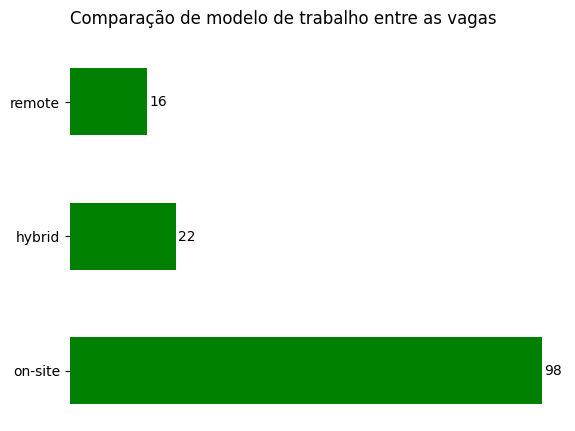

In [266]:
fig, ax = plt.subplots()

counts = df_dados_limpo["workplaceType"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de modelo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

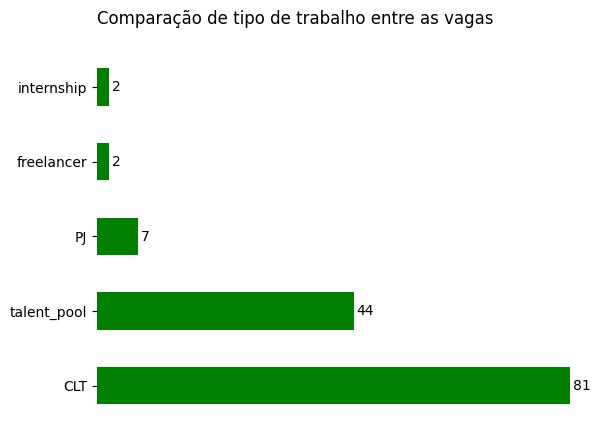

In [267]:
fig, ax = plt.subplots()

counts = df_dados_limpo["type"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de tipo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

O modelo mais comum dentre as vagas analisadas foi o modelo **presencial** <br>, enquanto para tipo de trabalho, o **efetivo/clt**.
Pelo domínio do presencial quando em comparação aos modelos híbrido e remoto, sugere-se que as empresas ainda querem seus funcionários 100% no local da empresa. <br>. Ainda mais visto que parte das vagas se concentram em **banco de talentos** (44) e **efetivo** (81)

Pode ser por fatores como:
* preferência da empresa pelo modelo
* adoção do modelo no início do funcionário na empresa
* empresa/área em que conversa com outros setores de modelo presencial na empresa

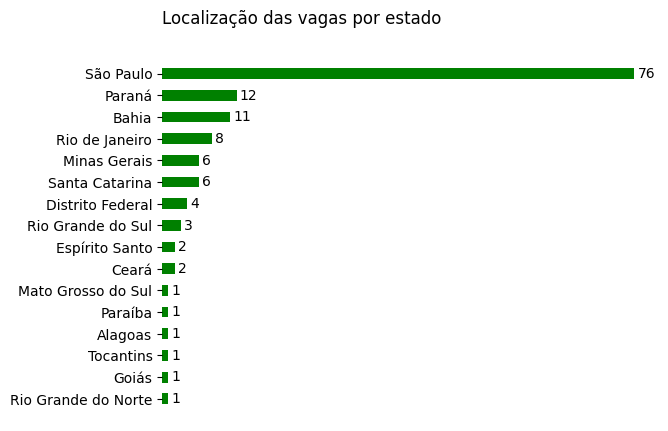

In [268]:
fig, ax = plt.subplots()

counts = df_dados_limpo["state"].value_counts()
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Localização das vagas por estado', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

A maioria das vagas estão concentradas no estado de São Paulo, sugerindo centralização do mercado nesse estado.

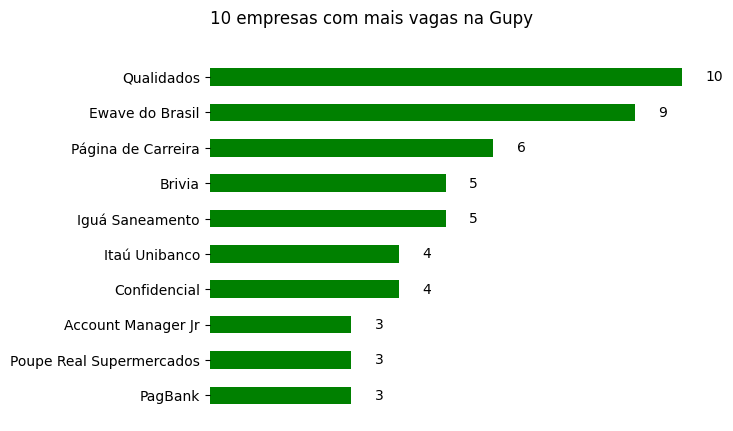

In [269]:
fig, ax = plt.subplots()

counts = df_dados_limpo["careerPageName"].value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 empresas com mais vagas na Gupy', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

Nessa análise há o viés da plataforma (Gupy), contabilizando apenas as empresas que usam essa plataforma e que estão com mais processos abertos simultaneamente.

Não existe concentração em poucas empresas, porque em comparação com os valores totais, as empresas com mais vagas não mostraram números dominantes. Há distribuição entre diferentes empresas.

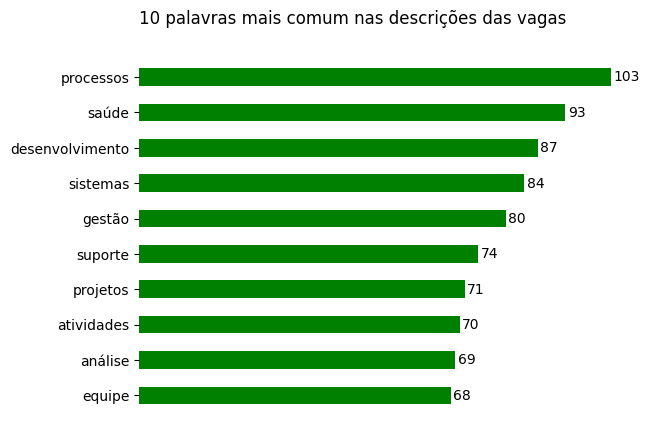

In [270]:
fig, ax = plt.subplots()

counts = pd.Series(words).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comum nas descrições das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

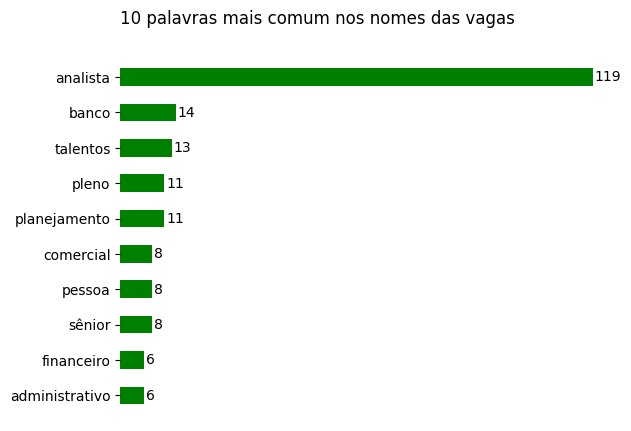

In [271]:
fig, ax = plt.subplots()

counts = pd.Series(words_name).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comum nos nomes das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

A maioria das vagas utiliza o termo “analista” de forma genérica, sem especificar claramente a especialização em dados. Ainda assim, houve predominância de vagas de nível pleno e sênior (com pouca especificação se comparar ao número total de vagas salvas). <br>

De acordo com as palavras mais comuns nos nomes das vagas e o tipo de trabalho, **banco** pode indicar que algumas das vagas não são vagas reais abertas, mas pools de candidatos. Com isso, parte das vagas pode não representar posições imediatas, mas cadastros para futuras oportunidas. <br>

Na descrição, algumas palavras fortes se destacaram, como: processos (103), gestão (80), suporte (74) e projetos (71), indicando que as vagas não são exclusivamente analíticas, mas também envolve atividades operacionais, suporte e gestão de processos. Trabalho em equipe frequentemente mencionado (68). <br>

As descrições tiveram foco em competências gerais e organizacionais, com menor destaque para ferramentas técnicas específicas. A palavra saúde teve grande destaque, podendo indicar concentração de vagas no setor de saúde.

* A maioria das vagas utiliza o termo "analista" de forma genérica, sem detalhar especialização
* As vagas estão requerindo nível pleno e sênior
* As descrições indicam forte foco em processos, suporte e gestão, e não apenas análise de dados
* Soft skills como comunicação e trabalho em equipe aparecem com frequência
* Há indícios de concentração em determinadores setores (saúde), podendo ter viés da plataforma
* Ferramentas técnicas específicas não se destacaram nas descrições analisadas
* O termo "dados" nas vagas não garante que a função seja altamente técnica, sendo muitas vezes associado a atividades operacionais e de suporte